# Texto Papal — Dei Verbum (IT→PT)
## Modelos: T5 (Flan-T5-large) e mBART-50

1. Carrega e executa os modelos T5 e mBART nos 26 parágrafos do Dei Verbum
2. Calcula BLEU por parágrafo (sacrebleu)
3. Calcula média e desvio padrão amostral
4. Gera tabela no formato da Tabela 1 do TCC

> **Requisito:** Runtime com GPU (T4 ou superior). Vá em Ambiente de execução → Alterar tipo de ambiente de execução → GPU

In [1]:
# ── Célula 1: Instalar dependências ──────────────────────────────────────────
!pip install -q sacrebleu transformers sentencepiece torch accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.7 MB/s eta 0:00:00


In [2]:
# ── Célula 2: Corpus — Dei Verbum (26 parágrafos, IT original) ───────────────

DEI_VERBUM_IT = [
    # Cap. I — A Revelação em Si Mesma (nn. 2–6)
    "Piacque a Dio nella sua bontà e sapienza rivelare se stesso e far conoscere il mistero della sua volontà.",
    "Con questa Rivelazione infatti Dio invisibile nel suo grande amore parla agli uomini come ad amici e si intrattiene con loro.",
    "La più profonda verità intorno a Dio e alla salvezza degli uomini ci viene illuminata per mezzo di questa Rivelazione.",
    "Questa economia della Rivelazione avviene con eventi e parole intimamente connessi tra loro.",
    "Per mezzo di tutta questa economia divina le parole di Dio e le opere di Dio si illuminano a vicenda.",
    "La Tradizione apostolica fa conoscere alla Chiesa il canone integrale dei libri sacri.",
    # Cap. II — A Transmissão da Revelação Divina (nn. 7–10)
    "Quello che Dio aveva rivelato per la salvezza di tutti i popoli lo volle conservato integro per sempre.",
    "La sacra Tradizione e la sacra Scrittura costituiscono un solo sacro deposito della parola di Dio.",
    "Il Magistero non è superiore alla parola di Dio ma la serve insegnando solo ciò che è stato trasmesso.",
    "È chiaro quindi che la sacra Tradizione la sacra Scrittura e il Magistero sono tra loro strettamente congiunti.",
    # Cap. III — A Inspiração e a Interpretação da Sagrada Escritura (nn. 11–13)
    "Le verità divinamente rivelate che sono contenute ed espresse nei libri della Sacra Scrittura furono scritte per ispirazione dello Spirito Santo.",
    "Poiché Dio nella sacra Scrittura ha parlato per mezzo di uomini alla maniera degli uomini.",
    "La sacra Scrittura deve essere letta e interpretata con l'aiuto dello stesso Spirito mediante il quale è stata scritta.",
    "Dio nella sacra Scrittura si è compiaciuto di condiscendere alla natura umana.",
    # Cap. IV — O Antigo Testamento (nn. 14–16)
    "Iddio con amorosa cura ha voluto che rimanessero i libri dell'Antico Testamento.",
    "I libri dell'Antico Testamento contengono cose incomplete e temporanee ma mostrano la vera pedagogia divina.",
    "Il Nuovo Testamento è nascosto nell'Antico e l'Antico è manifesto nel Nuovo.",
    # Cap. V — O Novo Testamento (nn. 17–20)
    "La parola di Dio che è forza di Dio per la salvezza di chiunque crede si trova nei libri del Nuovo Testamento.",
    "I Vangeli hanno un'origine apostolica e occupano a buon diritto un posto preminente tra tutti i Libri sacri.",
    "La formazione del Vangelo avviene in tre tappe: la vita di Gesù, la predicazione orale degli apostoli e la redazione scritta.",
    "Il Canone dei Libri Sacri comprende anche gli scritti apostolici che attestano la presenza operante di Cristo.",
    # Cap. VI — A Sagrada Escritura na Vida da Igreja (nn. 21–26)
    "La Chiesa ha sempre venerato le divine Scritture come ha fatto per il Corpo stesso del Signore.",
    "La sacra teologia si basa come su un fondamento perenne sulla parola di Dio scritta.",
    "I sacri autori per la composizione dei libri santi si sono serviti delle loro facoltà e capacità naturali.",
    "I traduttori devono rendere accessibile la parola di Dio nelle lingue di tutti i popoli.",
    "Occorre che i fedeli abbiano largo accesso alla sacra Scrittura per nutrirsene spiritualmente."
]

# Referência humana em português (tradução oficial — Dei Verbum, CNBB)
DEI_VERBUM_PT_REF = [
    "Aprouve a Deus em sua bondade e sabedoria revelar-se a si mesmo e dar a conhecer o mistério da sua vontade.",
    "Por esta Revelação o Deus invisível fala aos homens como a amigos e convive com eles no seu grande amor.",
    "A mais profunda verdade acerca de Deus e da salvação dos homens transparece para nós por meio desta Revelação.",
    "Esta economia da Revelação realiza-se por meio de ações e palavras intimamente ligadas entre si.",
    "Por meio de toda esta economia divina as palavras de Deus e as obras de Deus se iluminam mutuamente.",
    "A Tradição apostólica faz conhecer à Igreja o cânon integral dos livros sagrados.",
    "O que Deus havia revelado para a salvação de todos os povos quis que permanecesse integro para sempre.",
    "A sagrada Tradição e a sagrada Escritura constituem um único sagrado depósito da palavra de Deus.",
    "O Magistério não está acima da palavra de Deus mas a serve ensinando somente o que foi transmitido.",
    "É claro portanto que a sagrada Tradição a sagrada Escritura e o Magistério estão estreitamente unidos entre si.",
    "As verdades divinamente reveladas que se contêm e se exprimem nos livros da sagrada Escritura foram escritas por inspiração do Espírito Santo.",
    "Visto que Deus na sagrada Escritura falou por meio de homens à maneira dos homens.",
    "A sagrada Escritura deve ser lida e interpretada com o auxílio do mesmo Espírito pelo qual foi escrita.",
    "Deus na sagrada Escritura condescendeu com a natureza humana.",
    "Deus com amoroso cuidado quis que permanecessem os livros do Antigo Testamento.",
    "Os livros do Antigo Testamento contêm coisas imperfeitas e temporárias mas mostram a verdadeira pedagogia divina.",
    "O Novo Testamento está oculto no Antigo e o Antigo se manifesta no Novo.",
    "A palavra de Deus que é força de Deus para a salvação de todo crente encontra-se nos livros do Novo Testamento.",
    "Os Evangelhos têm origem apostólica e ocupam com razão lugar preeminente entre todos os Livros sagrados.",
    "A formação do Evangelho ocorre em três etapas: a vida de Jesus a pregação oral dos apóstolos e a redação escrita.",
    "O Cânon dos Livros Sagrados inclui também os escritos apostólicos que atestam a presença operante de Cristo.",
    "A Igreja sempre venerou as divinas Escrituras como venerou o próprio Corpo do Senhor.",
    "A sagrada teologia apoia-se como num fundamento perene na palavra de Deus escrita.",
    "Os sagrados autores para a composição dos livros sagrados serviram-se das suas faculdades e capacidades naturais.",
    "Os tradutores devem tornar acessível a palavra de Deus nas línguas de todos os povos.",
    "É necessário que os fiéis tenham amplo acesso à sagrada Escritura para nela se nutrirem espiritualmente."
]

assert len(DEI_VERBUM_IT) == 26, f"Esperado 26 parágrafos, encontrado {len(DEI_VERBUM_IT)}"
assert len(DEI_VERBUM_PT_REF) == 26, f"Esperado 26 referências, encontrado {len(DEI_VERBUM_PT_REF)}"
print(f"✓ Corpus carregado: {len(DEI_VERBUM_IT)} parágrafos")

✓ Corpus carregado: 26 parágrafos


In [3]:
# ── Célula 3: Imports e configuração ─────────────────────────────────────────
import torch
import statistics
import pandas as pd
from sacrebleu.metrics import BLEU
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    MBartForConditionalGeneration, MBart50TokenizerFast
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cpu":
    print("⚠ GPU não detectada. A execução será muito lenta. Habilite GPU no Colab.")

bleu_metric = BLEU(effective_order=True)

Device: cuda


In [4]:
# ── Célula 4: Função de cálculo BLEU por parágrafo ───────────────────────────

def calcular_bleu_por_paragrafo(traducoes, referencias):
    """Calcula BLEU individual por parágrafo (effective_order=True para sentenças curtas)."""
    scores = []
    for trad, ref in zip(traducoes, referencias):
        score = bleu_metric.sentence_score(trad, [ref])
        scores.append(round(score.score, 2))
    return scores

def estatisticas(scores, nome_modelo):
    """Imprime média, desvio padrão amostral e scores por parágrafo."""
    media = sum(scores) / len(scores)
    dp = statistics.stdev(scores)  # desvio padrão amostral (ddof=1)
    print(f"\n{'='*55}")
    print(f"MODELO: {nome_modelo}")
    print(f"{'='*55}")
    print(f"  MÉDIA  : {media:.2f}")
    print(f"  DP     : {dp:.2f}  (amostral, ddof=1)")
    print(f"  RESULTADO TABELA: {media:.2f} ± {dp:.2f}")
    print(f"\n  Scores por parágrafo:")
    for i, s in enumerate(scores, 1):
        print(f"    Par. {i:02d}: {s:.2f}")
    return media, dp

In [5]:
# ── Célula 5: MODELO 1 — Flan-T5-large ───────────────────────────────────────
# Carregamento (~1.5 GB) — pode demorar 2–4 min

print("Carregando Flan-T5-large...")
T5_MODEL_NAME = "google/flan-t5-large"

t5_tokenizer = AutoTokenizer.from_pretrained(T5_MODEL_NAME)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(
    T5_MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)
t5_model.eval()
print("✓ Flan-T5-large carregado")

Carregando Flan-T5-large...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

✓ Flan-T5-large carregado


In [6]:
# ── Célula 6: Tradução com T5 ─────────────────────────────────────────────────

def traduzir_t5(textos, tokenizer, model, device):
    """Traduz lista de textos IT→PT com Flan-T5."""
    traducoes = []
    prompt_prefix = "translate Italian to Portuguese: "
    for i, texto in enumerate(textos):
        entrada = prompt_prefix + texto
        inputs = tokenizer(
            entrada,
            return_tensors="pt",
            max_length=512,
            truncation=True
        ).to(device)
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=256,
                num_beams=4,
                early_stopping=True
            )
        trad = tokenizer.decode(output[0], skip_special_tokens=True)
        traducoes.append(trad)
        print(f"  [{i+1:02d}/26] {trad[:70]}")
    return traducoes

print("Traduzindo Dei Verbum com Flan-T5-large...")
t5_traducoes = traduzir_t5(DEI_VERBUM_IT, t5_tokenizer, t5_model, DEVICE)
print("\n✓ Traduções T5 concluídas")

Traduzindo Dei Verbum com Flan-T5-large...
  [01/26] Piace a Dios na sua bondade e sade rivelarse e conocere o mistero da s
  [02/26] Con esta Rivelaço, infatti, o Deus invisible nel suo grande amor parla
  [03/26] A verdade più profunda a riguardo a Deus e à salvezza dos seres humano
  [04/26] Esta economia da Rivelazione avviene con eventi e paroles intimamente 
  [05/26] Per mezzo di tutta questa economia divina, os palavras de Dios e os op
  [06/26] A tradiço apostolica fa conocere na Igreja o canone integrale de libri
  [07/26] O que Dios aveva revelado para a salvezza de todos os popolo o tutti c
  [08/26] A sacra Tradiço e a sacra Escritura formanse uma sola sacra deposito d
  [09/26] O Magisterio no é superiore à palavra de Deus, mas a escola a ensinar 
  [10/26] Essa é claro que a sacra Tradiço, a sacra Escritura e o Magisterio son
  [11/26] A verità divinamente revelata che so contenute e espresse nei libri da
  [12/26] Porque Deus na sacra Escritura haba falado durante meio 

In [7]:
# ── Célula 7: BLEU do T5 ─────────────────────────────────────────────────────

t5_scores = calcular_bleu_por_paragrafo(t5_traducoes, DEI_VERBUM_PT_REF)
t5_media, t5_dp = estatisticas(t5_scores, "Flan-T5-large")

# Guardar para tabela final
resultados_t5 = {
    "modelo": "Flan-T5-large",
    "scores": t5_scores,
    "media": round(t5_media, 2),
    "dp": round(t5_dp, 2),
    "traducoes": t5_traducoes
}


MODELO: Flan-T5-large
  MÉDIA  : 11.79
  DP     : 10.81  (amostral, ddof=1)
  RESULTADO TABELA: 11.79 ± 10.81

  Scores por parágrafo:
    Par. 01: 9.24
    Par. 02: 11.12
    Par. 03: 6.29
    Par. 04: 10.90
    Par. 05: 5.81
    Par. 06: 6.75
    Par. 07: 16.32
    Par. 08: 8.51
    Par. 09: 13.66
    Par. 10: 10.08
    Par. 11: 4.34
    Par. 12: 7.44
    Par. 13: 17.21
    Par. 14: 4.07
    Par. 15: 26.76
    Par. 16: 55.00
    Par. 17: 3.74
    Par. 18: 19.46
    Par. 19: 2.41
    Par. 20: 10.85
    Par. 21: 10.52
    Par. 22: 7.66
    Par. 23: 3.72
    Par. 24: 2.73
    Par. 25: 23.58
    Par. 26: 8.25


In [8]:
# ── Célula 8: Liberar memória do T5 antes de carregar mBART ──────────────────

del t5_model
del t5_tokenizer
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print("✓ Memória do T5 liberada")

✓ Memória do T5 liberada


In [9]:
# ── Célula 9: MODELO 2 — mBART-50 ────────────────────────────────────────────
# Carregamento (~2.4 GB) — pode demorar 3–5 min

print("Carregando mBART-50-many-to-many-mmt...")
MBART_MODEL_NAME = "facebook/mbart-large-50-many-to-many-mmt"

mbart_tokenizer = MBart50TokenizerFast.from_pretrained(MBART_MODEL_NAME)
mbart_model = MBartForConditionalGeneration.from_pretrained(
    MBART_MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32
).to(DEVICE)
mbart_model.eval()

# Configurar idiomas: italiano → português
mbart_tokenizer.src_lang = "it_IT"
MBART_TGT_LANG = "pt_XX"

print("✓ mBART-50 carregado")

Carregando mBART-50-many-to-many-mmt...


tokenizer_config.json:   0%|          | 0.00/529 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/649 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.43k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

✓ mBART-50 carregado


In [10]:
# ── Célula 10: Tradução com mBART ────────────────────────────────────────────

def traduzir_mbart(textos, tokenizer, model, device, tgt_lang):
    """Traduz lista de textos IT→PT com mBART-50."""
    traducoes = []
    tgt_lang_id = tokenizer.lang_code_to_id[tgt_lang]
    for i, texto in enumerate(textos):
        inputs = tokenizer(
            texto,
            return_tensors="pt",
            max_length=512,
            truncation=True
        ).to(device)
        with torch.no_grad():
            output = model.generate(
                **inputs,
                forced_bos_token_id=tgt_lang_id,
                max_new_tokens=256,
                num_beams=4,
                early_stopping=True
            )
        trad = tokenizer.decode(output[0], skip_special_tokens=True)
        traducoes.append(trad)
        print(f"  [{i+1:02d}/26] {trad[:70]}")
    return traducoes

print("Traduzindo Dei Verbum com mBART-50...")
mbart_traducoes = traduzir_mbart(
    DEI_VERBUM_IT, mbart_tokenizer, mbart_model, DEVICE, MBART_TGT_LANG
)
print("\n✓ Traduções mBART concluídas")

Traduzindo Dei Verbum com mBART-50...


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [01/26] Piace a God com a bondade e sabedoria de revelar-se a mystery de sua v


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [02/26] "" With this revelação, "" God invisible no seu grande amor, "" speaks


...

  [23/26] A sacral theologia é basem-se como uma base permanente na palavra escr


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [24/26] Os sacrifícios para a composição de livros sagrados utilizaram as suas


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [25/26] Os tradutores têm de tornar a palavra-passe possível nas línguas de to
  [26/26] O que acontece é que as pessoas têm muito acesso à Scripture para se n

✓ Traduções mBART concluídas


In [11]:
# ── Célula 11: BLEU do mBART ─────────────────────────────────────────────────

mbart_scores = calcular_bleu_por_paragrafo(mbart_traducoes, DEI_VERBUM_PT_REF)
mbart_media, mbart_dp = estatisticas(mbart_scores, "mBART-50")

resultados_mbart = {
    "modelo": "mBART-50",
    "scores": mbart_scores,
    "media": round(mbart_media, 2),
    "dp": round(mbart_dp, 2),
    "traducoes": mbart_traducoes
}


MODELO: mBART-50
  MÉDIA  : 15.71
  DP     : 13.63  (amostral, ddof=1)
  RESULTADO TABELA: 15.71 ± 13.63

  Scores por parágrafo:
    Par. 01: 12.64
    Par. 02: 11.51
    Par. 03: 6.82
    Par. 04: 22.72
    Par. 05: 1.92
    Par. 06: 25.75
    Par. 07: 41.00
    Par. 08: 39.85
    Par. 09: 25.96
    Par. 10: 7.76
    Par. 11: 6.46
    Par. 12: 5.54
    Par. 13: 2.28
    Par. 14: 4.46
    Par. 15: 11.63
    Par. 16: 44.99
    Par. 17: 6.61
    Par. 18: 1.09
    Par. 19: 11.64
    Par. 20: 24.13
    Par. 21: 5.88
    Par. 22: 13.26
    Par. 23: 8.84
    Par. 24: 13.76
    Par. 25: 44.52
    Par. 26: 7.44


In [12]:
# ── Célula 12: Tabela consolidada ────────────────────────────────────────────

print("\n" + "="*65)
print("TABELA CONSOLIDADA — BLEU por parágrafo — Texto Papal (IT→PT)")
print("="*65)

df = pd.DataFrame({
    "Parágrafo": [f"Par. {i+1:02d}" for i in range(26)],
    "T5 (Flan-T5-large)": t5_scores,
    "mBART-50": mbart_scores,
})

# Linha de média e DP
linha_media = pd.DataFrame([{
    "Parágrafo": "MÉDIA",
    "T5 (Flan-T5-large)": f"{resultados_t5['media']:.2f}",
    "mBART-50": f"{resultados_mbart['media']:.2f}",
}])
linha_dp = pd.DataFrame([{
    "Parágrafo": "DP (amostral)",
    "T5 (Flan-T5-large)": f"{resultados_t5['dp']:.2f}",
    "mBART-50": f"{resultados_mbart['dp']:.2f}",
}])
linha_resumo = pd.DataFrame([{
    "Parágrafo": "RESULTADO (Média ± DP)",
    "T5 (Flan-T5-large)": f"{resultados_t5['media']:.2f} ± {resultados_t5['dp']:.2f}",
    "mBART-50": f"{resultados_mbart['media']:.2f} ± {resultados_mbart['dp']:.2f}",
}])

df_final = pd.concat([df, linha_media, linha_dp, linha_resumo], ignore_index=True)
print(df_final.to_string(index=False))

print("\n" + "="*65)
print("VALORES PARA INSERIR NA TABELA 4 DO TCC:")
print(f"  T5    (Texto Papal): {resultados_t5['media']:.2f} ± {resultados_t5['dp']:.2f}")
print(f"  mBART (Texto Papal): {resultados_mbart['media']:.2f} ± {resultados_mbart['dp']:.2f}")
print("="*65)


TABELA CONSOLIDADA — BLEU por parágrafo — Texto Papal (IT→PT)
             Parágrafo T5 (Flan-T5-large)      mBART-50
               Par. 01               9.24         12.64
               Par. 02              11.12         11.51
               Par. 03               6.29          6.82
               Par. 04               10.9         22.72
               Par. 05               5.81          1.92
               Par. 06               6.75         25.75
               Par. 07              16.32          41.0
               Par. 08               8.51         39.85
               Par. 09              13.66         25.96
               Par. 10              10.08          7.76
               Par. 11               4.34          6.46
               Par. 12               7.44          5.54
               Par. 13              17.21          2.28
               Par. 14               4.07          4.46
               Par. 15              26.76         11.63
               Par. 16               55.0

In [13]:
# ── Célula 13: Visualizar traduções para conferência manual ──────────────────

print("\nCONFERÊNCIA DE TRADUÇÕES — primeiros 5 parágrafos")
print("="*65)
for i in range(5):
    print(f"\nParágrafo {i+1}:")
    print(f"  ORIGINAL  : {DEI_VERBUM_IT[i]}")
    print(f"  REFERÊNCIA: {DEI_VERBUM_PT_REF[i]}")
    print(f"  T5        : {t5_traducoes[i]}")
    print(f"  mBART     : {mbart_traducoes[i]}")
    print(f"  BLEU T5   : {t5_scores[i]:.2f}")
    print(f"  BLEU mBART: {mbart_scores[i]:.2f}")


CONFERÊNCIA DE TRADUÇÕES — primeiros 5 parágrafos

Parágrafo 1:
  ORIGINAL  : Piacque a Dio nella sua bontà e sapienza rivelare se stesso e far conoscere il mistero della sua volontà.
  REFERÊNCIA: Aprouve a Deus em sua bondade e sabedoria revelar-se a si mesmo e dar a conhecer o mistério da sua vontade.
  T5        : Piace a Dios na sua bondade e sade rivelarse e conocere o mistero da sua voluntad.
  mBART     : Piace a God com a bondade e sabedoria de revelar-se a mystery de sua vontade.
  BLEU T5   : 9.24
  BLEU mBART: 12.64

Parágrafo 2:
  ORIGINAL  : Con questa Rivelazione infatti Dio invisibile nel suo grande amore parla agli uomini come ad amici e si intrattiene con loro.
  REFERÊNCIA: Por esta Revelação o Deus invisível fala aos homens como a amigos e convive com eles no seu grande amor.
  T5        : Con esta Rivelaço, infatti, o Deus invisible nel suo grande amor parla aos homens como amigos e se entra com eles.
  mBART     : "" With this revelação, "" God invisible no seu g

In [14]:
# ── Célula 14: Exportar resultados para CSV ───────────────────────────────────

df_export = pd.DataFrame({
    "paragrafo": list(range(1, 27)),
    "original_it": DEI_VERBUM_IT,
    "referencia_pt": DEI_VERBUM_PT_REF,
    "traducao_t5": t5_traducoes,
    "traducao_mbart": mbart_traducoes,
    "bleu_t5": t5_scores,
    "bleu_mbart": mbart_scores,
})

df_export.to_csv("dei_verbum_t5_mbart_bleu.csv", index=False, encoding="utf-8-sig")
print("✓ Resultados exportados para dei_verbum_t5_mbart_bleu.csv")
print("  (Baixe o arquivo pelo painel de arquivos do Colab — ícone de pasta à esquerda)")

✓ Resultados exportados para dei_verbum_t5_mbart_bleu.csv
  (Baixe o arquivo pelo painel de arquivos do Colab — ícone de pasta à esquerda)


In [15]:
# ── Célula 15: RTT — Round-Trip Translation com mBART-large-50 ───────────────
# Estratégia: IT → PT (já feito) → PT → IT  (back-translation)
# BLEU-RTT = BLEU(back_traducao_IT, referencia_original_IT)
# O mBART ainda está carregado (célula 9). Se foi liberado, recarregue:
#   from transformers import MBartForConditionalGeneration, MBart50TokenizerFast
#   mbart_tokenizer = MBart50TokenizerFast.from_pretrained('facebook/mbart-large-50-many-to-many-mmt')
#   mbart_model = MBartForConditionalGeneration.from_pretrained(
#       'facebook/mbart-large-50-many-to-many-mmt',
#       torch_dtype=torch.float16 if DEVICE=='cuda' else torch.float32).to(DEVICE)
#   mbart_model.eval()

def traduzir_mbart_generica(textos, tokenizer, model, device, src_lang, tgt_lang):
    """Back-translation genérica com mBART-50 (qualquer par de idiomas)."""
    tokenizer.src_lang = src_lang
    tgt_lang_id = tokenizer.lang_code_to_id[tgt_lang]
    traducoes = []
    for i, texto in enumerate(textos):
        inputs = tokenizer(
            texto,
            return_tensors='pt',
            max_length=512,
            truncation=True
        ).to(device)
        with torch.no_grad():
            output = model.generate(
                **inputs,
                forced_bos_token_id=tgt_lang_id,
                max_new_tokens=256,
                num_beams=4,
                early_stopping=True
            )
        trad = tokenizer.decode(output[0], skip_special_tokens=True)
        traducoes.append(trad)
        print(f'  [{i+1:02d}/{len(textos)}] {trad[:70]}')
    return traducoes

# ── Passo 1: PT → IT (back-translation do Texto Papal) ───────────────────────
print('Back-translation mBART-50: PT → IT (Texto Papal)...')
mbart_rtt_papal = traduzir_mbart_generica(
    mbart_traducoes,           # saída IT→PT já calculada
    mbart_tokenizer, mbart_model, DEVICE,
    src_lang='pt_XX',
    tgt_lang='it_IT'
)
print('✓ Back-translation Papal concluída')

# ── Passo 2: BLEU-RTT Papal ──────────────────────────────────────────────────
rtt_scores_papal_mbart = calcular_bleu_por_paragrafo(mbart_rtt_papal, DEI_VERBUM_IT)
rtt_media_papal_mbart, rtt_dp_papal_mbart = estatisticas(rtt_scores_papal_mbart, 'RTT mBART-50 — Papal')

resultados_rtt_papal_mbart = {
    'modelo': 'mBART-50 (RTT)',
    'scores': rtt_scores_papal_mbart,
    'media': round(rtt_media_papal_mbart, 2),
    'dp': round(rtt_dp_papal_mbart, 2),
    'back_traducoes': mbart_rtt_papal
}
print(f'\nResultado RTT Papal (mBART): {rtt_media_papal_mbart:.2f} ± {rtt_dp_papal_mbart:.2f}')


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Back-translation mBART-50: PT → IT (Texto Papal)...


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [01/26] God ama la bontà e la saggezza di rivelare il mistero della sua volont


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  [23/26] La sacralità è basata su una base permanente sulla parola di Dio.


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [24/26] I sacrifico per la creazione di sacred libri usava le sue capacità.


[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [25/26] I've seen che i traduttori hanno bisogno di rendere il password possib
  [26/26] Quello che succede è che le persone hanno molto accesso alla Scripture
✓ Back-translation Papal concluída

MODELO: RTT mBART-50 — Papal
  MÉDIA  : 14.17
  DP     : 11.53  (amostral, ddof=1)
  RESULTADO TABELA: 14.17 ± 11.53

  Scores por parágrafo:
    Par. 01: 26.87
    Par. 02: 18.13
    Par. 03: 6.20
    Par. 04: 40.91
    Par. 05: 1.82
    Par. 06: 11.90
    Par. 07: 13.26
    Par. 08: 33.08
    Par. 09: 14.59
    Par. 10: 6.68
    Par. 11: 5.42
    Par. 12: 7.68
    Par. 13: 2.28
    Par. 14: 3.67
    Par. 15: 28.92
    Par. 16: 25.22
    Par. 17: 10.14
    Par. 18: 1.09
    Par. 19: 4.73
    Par. 20: 16.94
    Par. 21: 17.25
    Par. 22: 37.49
    Par. 23: 17.66
    Par. 24: 5.12
    Par. 25: 3.58
    Par. 26: 7.66

Resultado RTT Papal (mBART): 14.17 ± 11.53


In [16]:
# ── Célula 16: RTT com Flan-T5-large (back-translation PT→IT) ────────────────
# Recarrega T5 (foi liberado na célula 8)
print('Recarregando Flan-T5-large para back-translation...')
t5_tokenizer2 = AutoTokenizer.from_pretrained(T5_MODEL_NAME)
t5_model2 = AutoModelForSeq2SeqLM.from_pretrained(
    T5_MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == 'cuda' else torch.float32
).to(DEVICE)
t5_model2.eval()
print('✓ T5 recarregado')

def traduzir_t5_generica(textos, tokenizer, model, device, prompt_prefix):
    """Tradução com T5 usando prompt_prefix customizável."""
    traducoes = []
    for i, texto in enumerate(textos):
        entrada = prompt_prefix + texto
        inputs = tokenizer(
            entrada,
            return_tensors='pt',
            max_length=512,
            truncation=True
        ).to(device)
        with torch.no_grad():
            output = model.generate(
                **inputs,
                max_new_tokens=256,
                num_beams=4,
                early_stopping=True
            )
        trad = tokenizer.decode(output[0], skip_special_tokens=True)
        traducoes.append(trad)
        print(f'  [{i+1:02d}/{len(textos)}] {trad[:70]}')
    return traducoes

# ── Back-translation PT → IT (Texto Papal via T5) ────────────────────────────
print('Back-translation T5: PT → IT (Texto Papal)...')
t5_rtt_papal = traduzir_t5_generica(
    t5_traducoes,
    t5_tokenizer2, t5_model2, DEVICE,
    prompt_prefix='translate Portuguese to Italian: '
)
print('✓ Back-translation T5 Papal concluída')

rtt_scores_papal_t5 = calcular_bleu_por_paragrafo(t5_rtt_papal, DEI_VERBUM_IT)
rtt_media_papal_t5, rtt_dp_papal_t5 = estatisticas(rtt_scores_papal_t5, 'RTT T5 — Papal')

resultados_rtt_papal_t5 = {
    'modelo': 'T5 (RTT)',
    'scores': rtt_scores_papal_t5,
    'media': round(rtt_media_papal_t5, 2),
    'dp': round(rtt_dp_papal_t5, 2),
    'back_traducoes': t5_rtt_papal
}
print(f'\nResultado RTT Papal (T5): {rtt_media_papal_t5:.2f} ± {rtt_dp_papal_t5:.2f}')

# Libera T5 novamente
del t5_model2, t5_tokenizer2
if DEVICE == 'cuda': torch.cuda.empty_cache()
print('✓ T5 liberado')


Recarregando Flan-T5-large para back-translation...


Loading weights:   0%|          | 0/558 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


✓ T5 recarregado
Back-translation T5: PT → IT (Texto Papal)...
  [01/26] Piace di Diosa sua bondade e sade di rivelarsi e di conoscere il miste
  [02/26] Con questa Rivelaço, infatti, il Deo invisible nel suo grande amor par
  [03/26] La verità più profonda riguardo a Dio e a la salute dei essere umani è
  [04/26] Questa economia da Rivelazione avviene con eventi e parole intimamente
  [05/26] Per mezzo di tutta questa economia divina, i parole di Dios e i loro o
  [06/26] La tradizione apostolica fa conoscere in Igreja il canone integrale di
  [07/26] Questo che Dio aveva revelato per la salute di tutti i populi tutti av
  [08/26] La sacra Tradizione e la sacra Scrittura formano una sola sacra deposi
  [09/26] Il Magistro è più superiore alla parola di Dio, ma la scuola è insegna
  [10/26] Questo è claro che la sacra Tradizione, la sacra Scritura e il Magistr
  [11/26] A verità divinamente revelata che so contenute e espresse nei libri da
  [12/26] Perché Dio nel suo sacro Scrita ha p

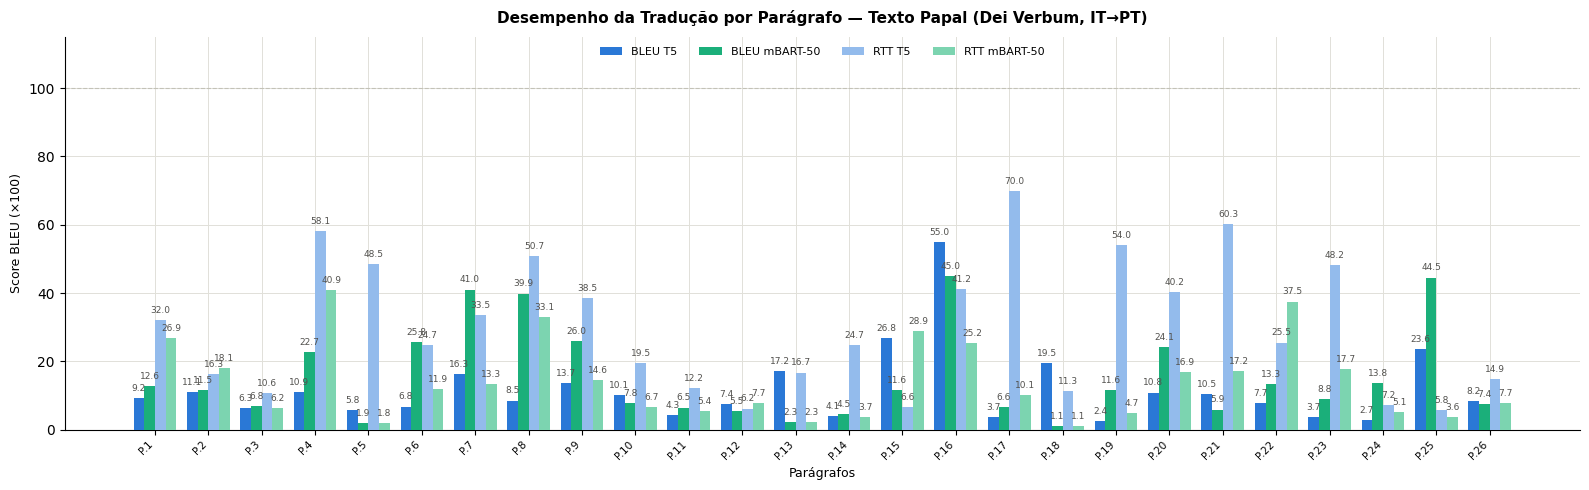

✓ Figura 1 salva: grafico_papal_bleu_rtt.png


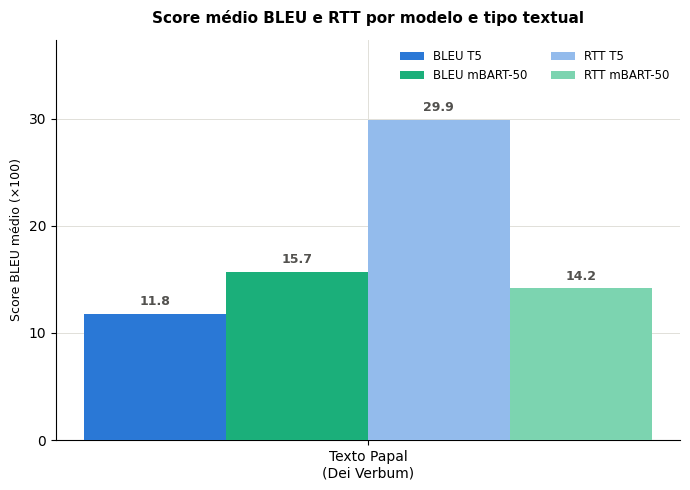

✓ Figura 2 salva: grafico_media_bleu_rtt.png

── Resumo final ─────────────────────────────────────────
  BLEU T5     | Papal: 11.79
  BLEU mBART  | Papal: 15.71
  RTT  T5     | Papal: 29.90
  RTT  mBART  | Papal: 14.16


In [18]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e1e0d9',
    'grid.linewidth': 0.7,
    'axes.axisbelow': True,
})

# Paleta
COR_T5    = '#2a78d6'
COR_MBART = '#1baf7a'
COR_RTT_T5    = '#93bbec'   # azul claro — RTT T5
COR_RTT_MBART = '#7cd4b0'   # verde claro — RTT mBART

def rotular(ax, bars, fmt='{:.1f}', fontsize=6.5, pad=1.5):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + pad,
                fmt.format(h),
                ha='center', va='bottom',
                fontsize=fontsize, color='#52514e'
            )

rotulos_papal = [f'P.{i+1}' for i in range(26)]
x = np.arange(26)
w = 0.20

# ════════════════════════════════════════════════════════════════════════════
# FIGURA 1 — BLEU por parágrafo (Texto Papal) — T5 e mBART + RTT
# ════════════════════════════════════════════════════════════════════════════
fig1, ax1 = plt.subplots(figsize=(16, 5))

b1 = ax1.bar(x - 1.5*w, t5_scores,           width=w, color=COR_T5,        label='BLEU T5',       zorder=3)
b2 = ax1.bar(x - 0.5*w, mbart_scores,         width=w, color=COR_MBART,     label='BLEU mBART-50', zorder=3)
b3 = ax1.bar(x + 0.5*w, rtt_scores_papal_t5,        width=w, color=COR_RTT_T5,    label='RTT T5',        zorder=3)
b4 = ax1.bar(x + 1.5*w, rtt_scores_papal_mbart,     width=w, color=COR_RTT_MBART, label='RTT mBART-50',  zorder=3)
rotular(ax1, b1); rotular(ax1, b2)
rotular(ax1, b3); rotular(ax1, b4)

ax1.set_title('Desempenho da Tradução por Parágrafo — Texto Papal (Dei Verbum, IT→PT)',
              fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel('Score BLEU (×100)', fontsize=9)
ax1.set_xlabel('Parágrafos', fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(rotulos_papal, fontsize=7.5, rotation=45, ha='right')
ax1.set_ylim(0, 115)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(20))
ax1.axhline(100, color='#c3c2b7', linewidth=0.8, linestyle='--', zorder=2)
ax1.legend(fontsize=8, framealpha=0, ncol=4, loc='upper center', bbox_to_anchor=(0.5, 1.0))
plt.tight_layout()
plt.savefig('grafico_papal_bleu_rtt.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura 1 salva: grafico_papal_bleu_rtt.png')

# ════════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Score médio BLEU e RTT por modelo e tipo textual
# ════════════════════════════════════════════════════════════════════════════
# Médias calculadas a partir das listas
papal_t5_avg     = np.mean(t5_scores)
papal_mbart_avg  = np.mean(mbart_scores)
rtt_papal_t5_avg    = np.mean(rtt_scores_papal_t5)
rtt_papal_mbart_avg = np.mean(rtt_scores_papal_mbart)

tipos    = ['Texto Papal\n(Dei Verbum)']
grupos   = [
    ('BLEU T5',       [papal_t5_avg],      COR_T5),
    ('BLEU mBART-50', [papal_mbart_avg],   COR_MBART),
    ('RTT T5',        [rtt_papal_t5_avg],  COR_RTT_T5),
    ('RTT mBART-50',  [rtt_papal_mbart_avg], COR_RTT_MBART),
]

n_grupos = len(grupos)
n_tipos  = len(tipos)
w2       = 0.15
offsets  = np.linspace(-(n_grupos-1)*w2/2, (n_grupos-1)*w2/2, n_grupos)
xm       = np.arange(n_tipos)

fig2, ax2 = plt.subplots(figsize=(7, 5))
for idx, (label, vals, cor) in enumerate(grupos):
    bars = ax2.bar(
        xm + offsets[idx], vals, width=w2,
        color=cor, label=label, zorder=3
    )
    for bar, val in zip(bars, vals):
        ax2.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#52514e'
        )

ax2.set_title('Score médio BLEU e RTT por modelo e tipo textual',
              fontsize=11, fontweight='bold', pad=12)
ax2.set_ylabel('Score BLEU médio (×100)', fontsize=9)
ax2.set_xticks(xm)
ax2.set_xticklabels(tipos, fontsize=10)
ax2.set_ylim(0, max(papal_t5_avg, papal_mbart_avg, rtt_papal_t5_avg, rtt_papal_mbart_avg) * 1.25)
ax2.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax2.legend(fontsize=8.5, framealpha=0, ncol=2, loc='upper right')
plt.tight_layout()
plt.savefig('grafico_media_bleu_rtt.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figura 2 salva: grafico_media_bleu_rtt.png')

print(f'\n── Resumo final ─────────────────────────────────────────')
print(f'  BLEU T5     | Papal: {papal_t5_avg:.2f}')
print(f'  BLEU mBART  | Papal: {papal_mbart_avg:.2f}')
print(f'  RTT  T5     | Papal: {rtt_papal_t5_avg:.2f}')
print(f'  RTT  mBART  | Papal: {rtt_papal_mbart_avg:.2f}')

In [19]:
# ── Célula 18: Exportar resultados RTT para CSV ──────────────────────────────

df_rtt = pd.DataFrame({
    'paragrafo':            list(range(1, 27)),
    'original_it':          DEI_VERBUM_IT,
    'trad_it_pt_t5':        t5_traducoes,
    'back_pt_it_t5':        t5_rtt_papal,
    'bleu_t5':              t5_scores,
    'rtt_bleu_t5':          rtt_scores_papal_t5,
    'trad_it_pt_mbart':     mbart_traducoes,
    'back_pt_it_mbart':     mbart_rtt_papal,
    'bleu_mbart':           mbart_scores,
    'rtt_bleu_mbart':       rtt_scores_papal_mbart,
})

df_rtt.to_csv('dei_verbum_bleu_rtt.csv', index=False, encoding='utf-8-sig')
print('✓ CSV exportado: dei_verbum_bleu_rtt.csv')
print('  (Baixe pelo painel de arquivos do Colab — ícone de pasta à esquerda)')
print()
print(df_rtt[['paragrafo','bleu_t5','rtt_bleu_t5','bleu_mbart','rtt_bleu_mbart']].to_string(index=False))


✓ CSV exportado: dei_verbum_bleu_rtt.csv
  (Baixe pelo painel de arquivos do Colab — ícone de pasta à esquerda)

 paragrafo  bleu_t5  rtt_bleu_t5  bleu_mbart  rtt_bleu_mbart
         1     9.24        31.99       12.64           26.87
         2    11.12        16.30       11.51           18.13
         3     6.29        10.58        6.82            6.20
         4    10.90        58.12       22.72           40.91
         5     5.81        48.46        1.92            1.82
         6     6.75        24.74       25.75           11.90
         7    16.32        33.49       41.00           13.26
         8     8.51        50.72       39.85           33.08
         9    13.66        38.46       25.96           14.59
        10    10.08        19.48        7.76            6.68
        11     4.34        12.21        6.46            5.42
        12     7.44         6.15        5.54            7.68
        13    17.21        16.70        2.28            2.28
        14     4.07        24.71 